# DHF - Lab 3: Hawkes Processes

AMRI Imad, CHIBA Nesrine, JAMAL Adonis

In [1]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm, shapiro, expon
import matplotlib.pyplot as plt
import time

np.random.seed(42)

### Configuration

Set `FULL_RUN = True` to use large horizons and more replications for
the final version. Keep `False` during development for faster execution.

In [2]:
FULL_RUN = True

if FULL_RUN:
    T_CONSIST = np.linspace(50,1000,10)#[50, 100, 250, 500, 1000, 2500]
    N_CONSIST = 30
    T_NORM = 1000
    N_NORM = 200
    T_GOF = 2000
    T_CHECK = 5000
    T_TIMING = [50, 100, 250, 500, 1000]
    N_TIMING = 3
    T_SINGLE = 500
    T_COMP = 500
    N_COMP = 50
    T_MSE = [100, 250, 500, 1000]
    N_MSE = 30
else:
    T_CONSIST = [50, 100, 250, 500]
    N_CONSIST = 15
    T_NORM = 500
    N_NORM = 80
    T_GOF = 500
    T_CHECK = 1000
    T_TIMING = [50, 100, 250, 500]
    N_TIMING = 2
    T_SINGLE = 300
    T_COMP = 300
    N_COMP = 20
    T_MSE = [100, 250, 500]
    N_MSE = 15

## Question 1: Properties of Hawkes MLE estimates

Consider simulations of a Hawkes process with constant baseline intensity $\mu$ and exponential kernel $\nu (t) = \alpha e^{-\beta t}$. Check that MLE estimators computed on simulated samples satisfy the expected statistical properties.

The stationarity condition is $\alpha / \beta < 1$.

We choose true parameters $\mu = 1.2$, $\alpha = 0.6$, $\beta = 0.8$
(branching ratio $\alpha/\beta = 0.75$, none equal to one). We simulate
this process using Ogata's thinning algorithm, compute the MLE on each
sample, and verify consistency and asymptotic normality.

### Simulation by Ogata thinning

The thinning algorithm generates candidate inter-arrival times from an
exponential distribution with rate equal to the current intensity upper
bound $\lambda^*$. Each candidate is accepted with probability
$\lambda(t)/\lambda^*$. For exponential kernels the jump part of the
intensity is updated recursively, avoiding a loop over all past events.

In [3]:
def simulate_hawkes_thinning(mu, alpha, beta, T):
    events = []
    t = 0.0
    intensity = mu
    lam_star = mu
    while t < T:
        u = np.random.exponential(1.0 / lam_star)
        t += u
        if t >= T:
            break
        intensity = mu + (intensity - mu) * np.exp(-beta * u)
        if np.random.uniform() <= intensity / lam_star:
            events.append(t)
            intensity += alpha
        lam_star = intensity
    return np.array(events)

### Log-likelihood with recursive computation

The log-likelihood for a Hawkes process with P-exponential kernel
observed on $[0,T]$ is (Ogata, 1981):

$$\log \mathcal{L}_T = - \mu T + \sum_{i=1}^n \log\Big(\mu + \sum_{j=1}^P \alpha_j R_j(i)\Big) - \sum_{i=1}^n \sum_{j=1}^P \frac{\alpha_j}{\beta_j}\big(1 - e^{-\beta_j(T-t_i)}\big)$$

where $R_j(1) = 0$ and
$R_j(i) = e^{-\beta_j(t_i-t_{i-1})}(1+R_j(i-1))$.

In the case of a P-exponential kernel, this gives $O(n)$ complexity.

In [4]:
def hawkes_negloglik(params, events, T):
    mu, alpha, beta = params
    if mu <= 0 or alpha <= 0 or beta <= 0 or alpha / beta >= 1:
        return 1e10
    n = len(events)
    if n == 0:
        return mu * T
    R = 0.0
    ll = 0.0
    for i in range(n):
        if i > 0:
            R = np.exp(
                -beta * (events[i] - events[i - 1])
            ) * (1 + R)
        lam_i = mu + alpha * R
        if lam_i <= 0:
            return 1e10
        ll += np.log(lam_i)
    compensator = mu * T + (alpha / beta) * np.sum(
        1 - np.exp(-beta * (T - events))
    )
    return -(ll - compensator)


def fit_hawkes_mle(events, T, x0=None):
    events = np.asarray(events, dtype=float)
    n = len(events)
    if x0 is None:
        x0 = [n / (2.0 * T), 0.3, 1.0]

    res = minimize(
        hawkes_negloglik,
        x0,
        args=(events, T),
        method='L-BFGS-B',                     # handles bounds natively
        bounds=[(1e-6, None), (1e-6, None), (1e-6, None)],
        options={
            'maxiter': 10_000,
            'ftol': 1e-12,   
            'gtol': 1e-8,    
        },
    )
    return res.x

### Consistency of the MLE

Ogata (1978) proved that the MLE $\hat{\theta}_T$ is consistent: $$\forall \epsilon > 0, \quad \lim_{T \to \infty} P\left(\|\hat{\theta}_T - \theta^*\| > \epsilon\right) = 0$$


We check this by running multiple independent simulations for increasing
horizons $T$ and plotting the mean and standard deviation of the
estimates.

In [5]:
mu_true, alpha_true, beta_true = 1.2, 0.6, 0.8

results = {p: {T: [] for T in T_CONSIST}
           for p in ['mu', 'alpha', 'beta']}

for T in T_CONSIST:
    for _ in range(N_CONSIST):
        ev = simulate_hawkes_thinning(
            mu_true, alpha_true, beta_true, T
        )
        if len(ev) < 10:
            continue
        est = fit_hawkes_mle(ev, T)
        results['mu'][T].append(est[0])
        results['alpha'][T].append(est[1])
        results['beta'][T].append(est[2])

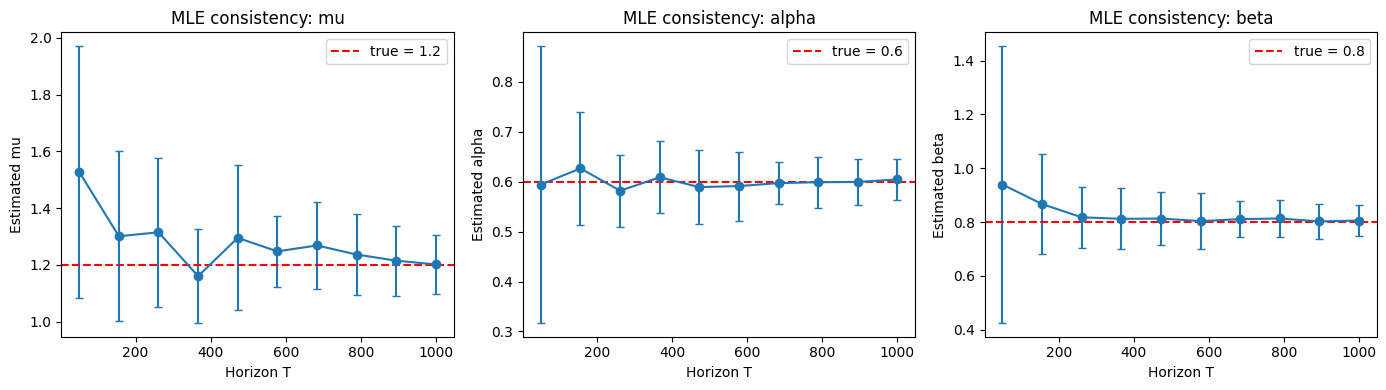

In [6]:
true_vals = {
    'mu': mu_true,
    'alpha': alpha_true,
    'beta': beta_true
}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, name in zip(axes, ['mu', 'alpha', 'beta']):
    means = [np.mean(results[name][T]) for T in T_CONSIST]
    stds = [np.std(results[name][T]) for T in T_CONSIST]
    ax.errorbar(
        T_CONSIST, means, yerr=stds,
        fmt='o-', capsize=3
    )
    ax.axhline(
        true_vals[name], color='r', ls='--',
        label=f'true = {true_vals[name]}'
    )
    ax.set_xlabel('Horizon T')
    ax.set_ylabel(f'Estimated {name}')
    ax.set_title(f'MLE consistency: {name}')
    ax.legend()

plt.tight_layout()
plt.show()

The estimates converge to the true values as $T$ increases and the
standard deviation shrinks. This confirms the consistency of the MLE.

### Asymptotic normality

The MLE satisfies $$\sqrt{T}(\hat{\theta}_T - \theta^*) \xrightarrow{d}
\mathcal{N}(0, I^{-1}(\theta^*))$$ where $I(\theta) = \left( E\left[ \frac{1}{\lambda} \frac{\partial \lambda}{\partial \theta_i} \frac{\partial \lambda}{\partial \theta_j} \right] \right)_{i,j}$.

We verify this by running many replications at a
fixed large horizon and checking the empirical distribution of the
rescaled estimates.

In [7]:
ests_norm = np.zeros((N_NORM, 3))

for i in range(N_NORM):
    ev = simulate_hawkes_thinning(
        mu_true, alpha_true, beta_true, T_NORM
    )
    if len(ev) < 10:
        ests_norm[i] = np.nan
        continue
    ests_norm[i] = fit_hawkes_mle(ev, T_NORM)

mask = ~np.isnan(ests_norm[:, 0])
ests_norm = ests_norm[mask]

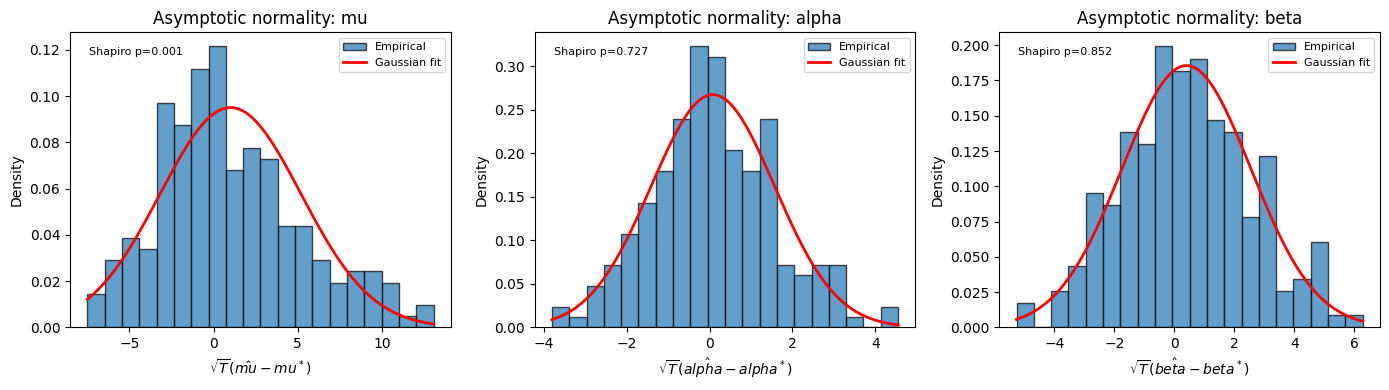

In [8]:
param_names = ['mu', 'alpha', 'beta']
true_arr = np.array([mu_true, alpha_true, beta_true])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, name, true_v, col in zip(
    axes, param_names, true_arr, range(3)
):
    centered = np.sqrt(T_NORM) * (ests_norm[:, col] - true_v)
    ax.hist(
        centered, bins=20, density=True, alpha=0.7,
        edgecolor='k', label='Empirical'
    )
    xr = np.linspace(centered.min(), centered.max(), 200)
    ax.plot(
        xr,
        norm.pdf(xr, centered.mean(), centered.std()),
        'r-', lw=2, label='Gaussian fit'
    )
    ax.set_xlabel(
        r'$\sqrt{T}(\hat{' + name
        + r'} - ' + name + r'^*)$'
    )
    ax.set_ylabel('Density')
    ax.set_title(f'Asymptotic normality: {name}')
    ax.legend(fontsize=8)
    _, pval = shapiro(centered)
    ax.text(
        0.05, 0.95, f'Shapiro p={pval:.3f}',
        transform=ax.transAxes, va='top', fontsize=8
    )

plt.tight_layout()
plt.show()

The histograms of $\sqrt{T}(\hat{\theta}_T - \theta^*)$ closely
follow a Gaussian density and the Shapiro-Wilk p-values confirm that
we cannot reject the normality hypothesis, validating the asymptotic
normality result from Ogata (1978).

### Goodness of fit via change of time

By the time-change theorem (Bremaud, 1981), the compensator residuals
$\Lambda(t_{i-1}, t_i) = \int_{t_{i-1}}^{t_i} \lambda(s)\,ds$ should
be i.i.d. $\text{Exp}(1)$ under the correct model. 

For the exponential kernel this integral is computed recursively using $A(1)=1$ and $A(i) = 1 + e^{-\beta(t_i - t_{i-1})} A(i-1)$.

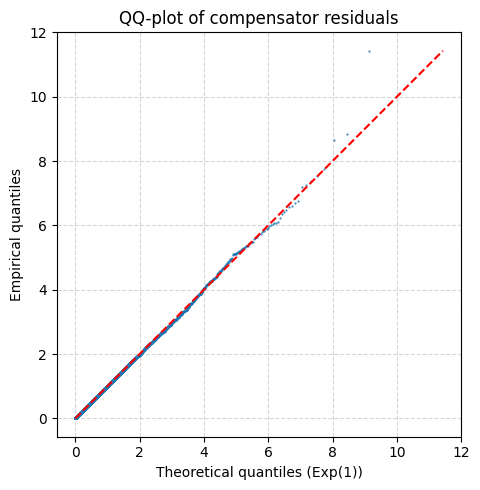

In [9]:
def compensator_residuals(events, mu, alpha, beta):
    n = len(events)
    residuals = np.zeros(n - 1)
    A = 1.0
    for i in range(1, n):
        dt = events[i] - events[i - 1]
        residuals[i - 1] = (
            mu * dt
            + (alpha / beta)
            * (1 - np.exp(-beta * dt)) * A
        )
        A = 1.0 + np.exp(-beta * dt) * A
    return residuals


ev_gof = simulate_hawkes_thinning(
    mu_true, alpha_true, beta_true, T_GOF
)
est_gof = fit_hawkes_mle(ev_gof, T_GOF)
res = compensator_residuals(ev_gof, *est_gof)
res_sorted = np.sort(res)
n_res = len(res_sorted)
theo_q = expon.ppf(
    np.arange(1, n_res + 1) / (n_res + 1)
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(theo_q, res_sorted, '.', markersize=1)
lim = max(theo_q.max(), res_sorted.max())
ax.plot([0, lim], [0, lim], 'r--')
ax.set_xlabel('Theoretical quantiles (Exp(1))')
ax.set_ylabel('Empirical quantiles')
ax.set_title('QQ-plot of compensator residuals')
ax.set_aspect('equal')
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

The QQ-plot follows the diagonal closely, confirming the goodness of
fit of the estimated model on the simulated data.

---

## Question 2: Computational cost of Hawkes simulators

Compare the computational cost of several simulation algorithms (and possibly several implementations of the same algorithm) and several types of kernels. Explain your experiments in details. Check that all your simulators are correct. Explain your results on the computational cost.

We compare three simulation algorithms:
1. Thinning with recursive intensity update (Ogata, 1981): $O(n)$ total for exponential kernels.
2. Thinning with naive intensity evaluation: each candidate requires summing over all past events, $O(n^2)$ total.
3. Cluster (branching) simulation: immigrants from a Poisson process, offspring via inverse-CDF sampling.

We also test thinning (naive) on a power-law kernel $\nu(t) = \alpha(1+t)^{-\gamma}$ (with $\gamma > 1$) to illustrate the effect of a slowly-decaying kernel with no recursive shortcut.

### General thinning (no recursion)

In [10]:
def kernel_exp(t, alpha, beta):
    return alpha * np.exp(-beta * t)


def kernel_powerlaw(t, alpha, gamma):
    return alpha * (1.0 + t) ** (-gamma)


def simulate_hawkes_general(mu, kernel_func, kparams, T):
    events = []
    t = 0.0
    lam_star = mu
    while t < T:
        u = np.random.exponential(1.0 / lam_star)
        t += u
        if t >= T:
            break
        ev_arr = np.array(events) if events else np.array([])
        lam = mu
        if len(ev_arr) > 0:
            lam += np.sum(
                kernel_func(t - ev_arr, *kparams)
            )
        if np.random.uniform() <= lam / lam_star:
            events.append(t)
            lam_star = lam + kernel_func(0.0, *kparams)
        else:
            lam_star = lam
    return np.array(events)

### Cluster (branching) simulation

For each parent at $t_p$, the number of children in $[t_p, T]$ is Poisson
with mean $(\alpha/\beta)(1 - e^{-\beta(T - t_p)})$. Each child time is
sampled by inverting the CDF of the truncated exponential kernel.

In [11]:
def simulate_hawkes_cluster(mu, alpha, beta, T):
    immigrants = []
    t = 0.0
    while True:
        t += np.random.exponential(1.0 / mu)
        if t >= T:
            break
        immigrants.append(t)

    all_events = list(immigrants)
    parents = list(immigrants)
    while parents:
        children = []
        for tp in parents:
            remaining = T - tp
            if remaining <= 0:
                continue
            nc = np.random.poisson(
                (alpha / beta)
                * (1 - np.exp(-beta * remaining))
            )
            for _ in range(nc):
                u = np.random.uniform()
                ct = tp - (1.0 / beta) * np.log(
                    1 - u * (
                        1 - np.exp(-beta * remaining)
                    )
                )
                if ct < T:
                    children.append(ct)
        all_events.extend(children)
        parents = children

    all_events.sort()
    return np.array(all_events)

### Correctness check

Before timing, we verify that all simulators produce the expected
average intensity $\lambda_\infty = \mu / (1 - \alpha/\beta)$.

In [12]:
mu_c, alpha_c, beta_c = 1.2, 0.6, 0.8
lam_inf = mu_c / (1 - alpha_c / beta_c)

print(f'Theoretical average intensity: {lam_inf:.3f}')
print()
for label, sim in [
    ('Thinning (recursive)',
     lambda: simulate_hawkes_thinning(
         mu_c, alpha_c, beta_c, T_CHECK)),
    ('Thinning (general, exp)',
     lambda: simulate_hawkes_general(
         mu_c, kernel_exp, (alpha_c, beta_c), T_CHECK)),
    ('Cluster',
     lambda: simulate_hawkes_cluster(
         mu_c, alpha_c, beta_c, T_CHECK)),
]:
    ev = sim()
    print(
        f'{label}: N={len(ev)}, '
        f'empirical rate = {len(ev)/T_CHECK:.3f}'
    )

Theoretical average intensity: 4.800

Thinning (recursive): N=22716, empirical rate = 4.543
Thinning (general, exp): N=23514, empirical rate = 4.703
Cluster: N=24067, empirical rate = 4.813


All three simulators produce empirical rates close to the theoretical
value, confirming their correctness.

### Timing comparison

In [13]:
timings = {}
event_counts = {}

configs = [
    ('Thinning recursive (exp)',
     lambda T: simulate_hawkes_thinning(
         mu_c, alpha_c, beta_c, T)),
    ('Thinning general (exp)',
     lambda T: simulate_hawkes_general(
         mu_c, kernel_exp, (alpha_c, beta_c), T)),
    ('Cluster (exp)',
     lambda T: simulate_hawkes_cluster(
         mu_c, alpha_c, beta_c, T)),
    ('Thinning general (power-law)',
     lambda T: simulate_hawkes_general(
         mu_c, kernel_powerlaw, (alpha_c, 2.5), T)),
]

for label, sim_fn in configs:
    timings[label] = []
    event_counts[label] = []
    for T in T_TIMING:
        elapsed = []
        n_ev = 0
        for _ in range(N_TIMING):
            t0 = time.perf_counter()
            ev = sim_fn(T)
            elapsed.append(time.perf_counter() - t0)
            n_ev = len(ev)
        timings[label].append(np.median(elapsed))
        event_counts[label].append(n_ev)

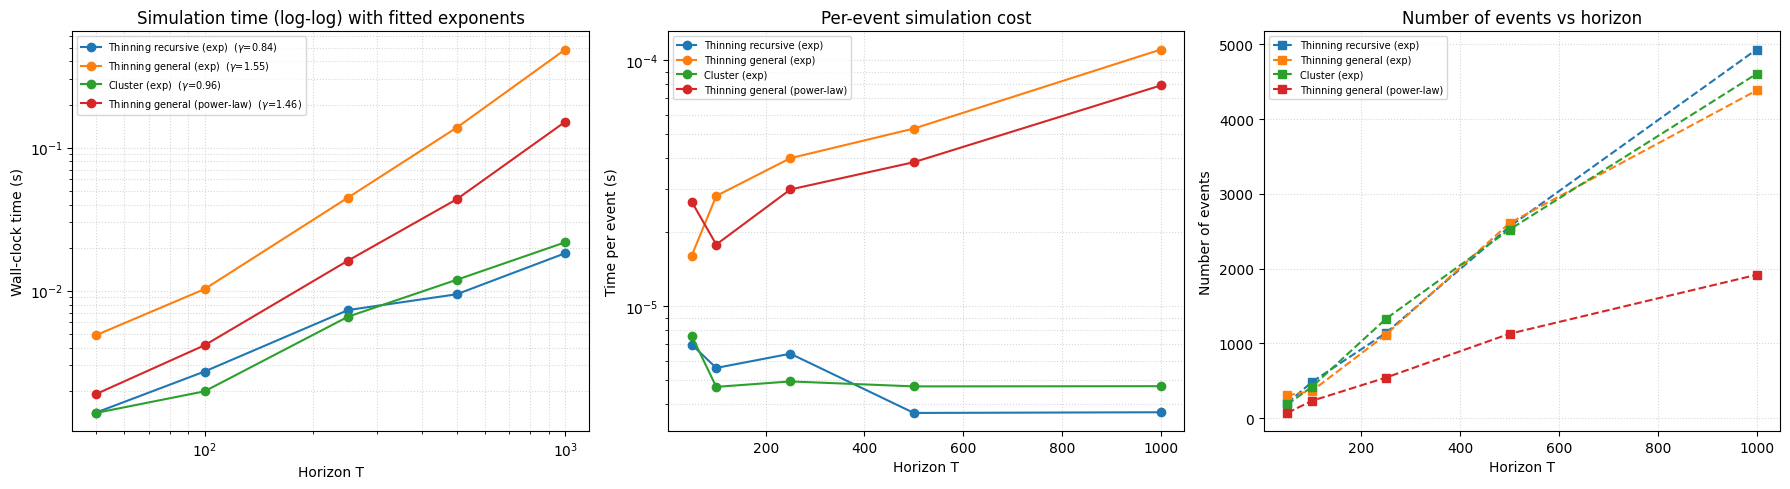

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Log-log timing with fitted complexity exponents
ax = axes[0]
for label, vals in timings.items():
    log_T = np.log(T_TIMING)
    log_t = np.log(np.array(vals) + 1e-15)
    gamma = np.polyfit(log_T, log_t, 1)[0]
    ax.plot(T_TIMING, vals, 'o-',
            label=f'{label}  ($\\gamma$={gamma:.2f})')
ax.set_xlabel('Horizon T')
ax.set_ylabel('Wall-clock time (s)')
ax.set_title('Simulation time (log-log) with fitted exponents')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=7)
ax.grid(True, which='both', ls=':', alpha=0.5)

# Per-event cost
ax = axes[1]
for label in timings:
    per_event = [
        t / max(n, 1)
        for t, n in zip(timings[label], event_counts[label])
    ]
    ax.plot(T_TIMING, per_event, 'o-', label=label)
ax.set_xlabel('Horizon T')
ax.set_ylabel('Time per event (s)')
ax.set_title('Per-event simulation cost')
ax.set_yscale('log')
ax.legend(fontsize=7)
ax.grid(True, which='both', ls=':', alpha=0.5)

# Event counts
ax = axes[2]
for label, vals in event_counts.items():
    ax.plot(T_TIMING, vals, 's--', label=label)
ax.set_xlabel('Horizon T')
ax.set_ylabel('Number of events')
ax.set_title('Number of events vs horizon')
ax.legend(fontsize=7)
ax.grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.show()

**Analysis and interpretation:**
- The log-log plot confirms the theoretical complexities via fitted exponents $\gamma$: the recursive thinning and cluster methods scale roughly linearly ($\gamma \approx 1$), while the general thinning scales super-linearly ($\gamma > 1$) since each candidate requires a full sum over all past events.
- The per-event cost panel isolates algorithmic overhead from event count: $O(n)$ methods show a flat per-event cost, while $O(n^2)$ methods show growing per-event cost as $T$ (and $n$) increase.
- The event count grows linearly with $T$ for all methods, as expected for a stationary process.

To go further, we measure the acceptance rate of the thinning algorithms and study the effect of the branching ratio $\alpha/\beta$.

In [15]:
def simulate_hawkes_thinning_instrumented(mu, alpha, beta, T):
    events = []
    t = 0.0
    intensity = mu
    lam_star = mu
    n_candidates = 0
    while t < T:
        u = np.random.exponential(1.0 / lam_star)
        t += u
        if t >= T:
            break
        n_candidates += 1
        intensity = mu + (intensity - mu) * np.exp(-beta * u)
        if np.random.uniform() <= intensity / lam_star:
            events.append(t)
            intensity += alpha
        lam_star = intensity
    n_accepted = len(events)
    return np.array(events), n_accepted, n_candidates


def simulate_hawkes_general_instrumented(mu, kernel_func, kparams, T):
    events = []
    t = 0.0
    lam_star = mu
    n_candidates = 0
    while t < T:
        u = np.random.exponential(1.0 / lam_star)
        t += u
        if t >= T:
            break
        n_candidates += 1
        ev_arr = np.array(events) if events else np.array([])
        lam = mu
        if len(ev_arr) > 0:
            lam += np.sum(kernel_func(t - ev_arr, *kparams))
        if np.random.uniform() <= lam / lam_star:
            events.append(t)
            lam_star = lam + kernel_func(0.0, *kparams)
        else:
            lam_star = lam
    n_accepted = len(events)
    return np.array(events), n_accepted, n_candidates


T_acc = 1000
configs_acc = [
    ('Recursive (exp)',
     lambda: simulate_hawkes_thinning_instrumented(
         mu_c, alpha_c, beta_c, T_acc)),
    ('General (exp)',
     lambda: simulate_hawkes_general_instrumented(
         mu_c, kernel_exp, (alpha_c, beta_c), T_acc)),
    ('General (power-law)',
     lambda: simulate_hawkes_general_instrumented(
         mu_c, kernel_powerlaw, (alpha_c, 2.5), T_acc)),
]

print(f'{"Method":<28s} {"Accepted":>10s} {"Candidates":>12s} '
      f'{"Accept rate":>12s}')
print('-' * 64)
for label, sim_fn in configs_acc:
    _, n_acc, n_cand = sim_fn()
    rate = n_acc / n_cand if n_cand > 0 else 0
    print(f'{label:<28s} {n_acc:10d} {n_cand:12d} '
          f'{rate:12.2%}')

Method                         Accepted   Candidates  Accept rate
----------------------------------------------------------------
Recursive (exp)                    4799         5318       90.24%
General (exp)                      5312         5852       90.77%
General (power-law)                1928         2377       81.11%


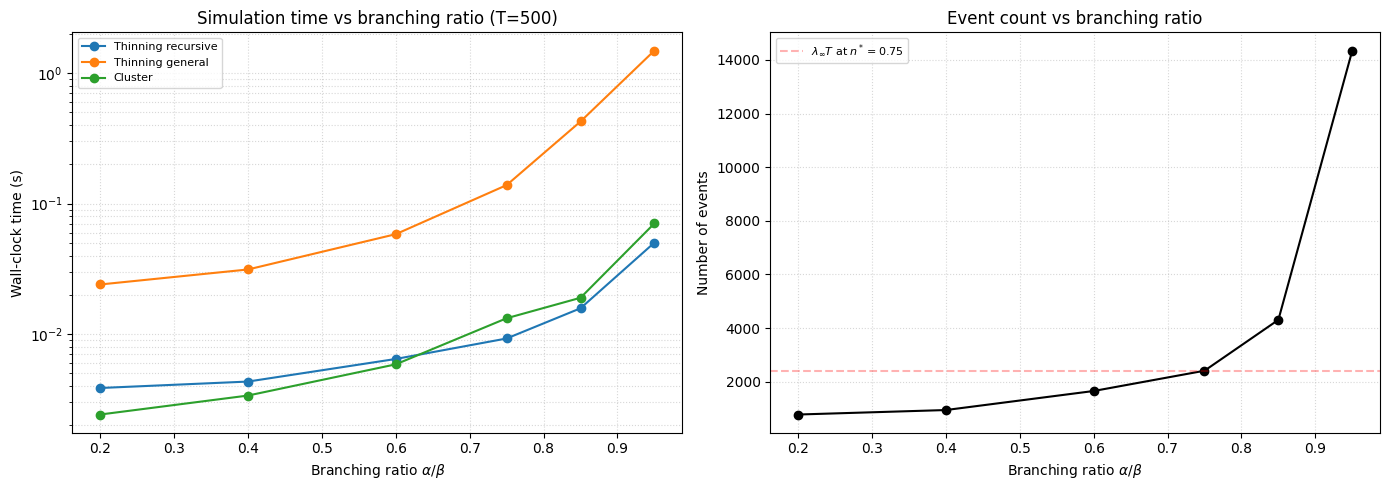

In [16]:
ratios = [0.2, 0.4, 0.6, 0.75, 0.85, 0.95]
T_br = 500
beta_br = 1.0

br_timings = {
    'Thinning recursive': [],
    'Thinning general': [],
    'Cluster': [],
}
br_nevents = []

for r in ratios:
    alpha_br = r * beta_br
    ev_counts = []
    for label, sim_fn in [
        ('Thinning recursive',
         lambda: simulate_hawkes_thinning(
             mu_c, alpha_br, beta_br, T_br)),
        ('Thinning general',
         lambda: simulate_hawkes_general(
             mu_c, kernel_exp, (alpha_br, beta_br), T_br)),
        ('Cluster',
         lambda: simulate_hawkes_cluster(
             mu_c, alpha_br, beta_br, T_br)),
    ]:
        t0 = time.perf_counter()
        ev = sim_fn()
        elapsed = time.perf_counter() - t0
        br_timings[label].append(elapsed)
        if label == 'Thinning recursive':
            ev_counts.append(len(ev))
    br_nevents.append(ev_counts[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label, vals in br_timings.items():
    ax.plot(ratios, vals, 'o-', label=label)
ax.set_xlabel(r'Branching ratio $\alpha/\beta$')
ax.set_ylabel('Wall-clock time (s)')
ax.set_title(f'Simulation time vs branching ratio (T={T_br})')
ax.set_yscale('log')
ax.legend(fontsize=8)
ax.grid(True, which='both', ls=':', alpha=0.5)

ax = axes[1]
ax.plot(ratios, br_nevents, 'ko-')
ax.axhline(
    mu_c / (1 - 0.75) * T_br, color='r', ls='--',
    alpha=0.3, label=r'$\lambda_\infty T$ at $n^*=0.75$'
)
ax.set_xlabel(r'Branching ratio $\alpha/\beta$')
ax.set_ylabel('Number of events')
ax.set_title('Event count vs branching ratio')
ax.legend(fontsize=8)
ax.grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.show()

**Acceptance rate:**
The recursive thinning achieves a high acceptance rate because the upper bound $\lambda^*$ is set to the current intensity right after each event (tight bound). The power-law kernel shows a lower rate because its slowly-decaying tail causes a looser upper bound between events, wasting more candidates.

**Branching ratio effect:**
As $\alpha/\beta$ increases toward 1 (critical regime), the number of events grows sharply (consistent with $\lambda_\infty = \mu/(1-n^*)$), and so does the computation time for all methods. The general thinning suffers most because its $O(n^2)$ cost amplifies the effect of having more events. The cluster method also shows signs of slowing at very high ratios as it builds deeper branching trees, while the recursive thinning remains the fastest across all regimes.

---

## Question 3: MLE vs EM estimation

Compare the MLE and the EM estimation a Hawkes process with constant baseline intensity $\mu$ and exponential kernel $\nu(t) = \alpha e^{-\beta t}$.

We implement the EM algorithm for a Hawkes process with constant baseline $\mu$ and exponential kernel $\nu(t) = \alpha e^{-\beta t}$ using the approximate update equations from the lecture (Lewis and Mohler, 2011).

### EM algorithm

At each iteration:
- E-step: compute probabilities
$p_{ii}^{(k)} = \mu^{(k)} / \lambda^{(k)}(t_i)$ and
$p_{ij}^{(k)} = \alpha^{(k)} e^{-\beta^{(k)}(t_i - t_j)} / \lambda^{(k)}(t_i)$ for $j < i$.
- M-step: update parameters via closed-form (approximate) formulas.

We use the recursion $S(i) = e^{-\beta(t_i - t_{i-1})}(\alpha + S(i-1))$
for $O(n)$ evaluation of the E-step sums, instead of the naive $O(n^2)$
double loop.

In [17]:


def _bisect_root(f, a, b, tol=1e-10, max_iter=200):
    fa = f(a)
    fb = f(b)

    if not np.isfinite(fa) or not np.isfinite(fb):
        raise ValueError("Non-finite function value in bracketing interval.")

    if fa == 0.0:
        return a
    if fb == 0.0:
        return b
    if fa * fb > 0:
        raise ValueError("Root is not bracketed on [a, b].")

    for _ in range(max_iter):
        m = 0.5 * (a + b)
        fm = f(m)

        if not np.isfinite(fm):
            raise ValueError("Non-finite function value during bisection.")

        if abs(fm) < tol or 0.5 * (b - a) < tol:
            return m

        if fa * fm <= 0:
            b, fb = m, fm
        else:
            a, fa = m, fm

    return 0.5 * (a + b)

def fit_hawkes_em(events, T, max_iter=300, tol=1e-6,
                  mu0=None, alpha0=None, beta0=None,
                  beta_min=1e-6, beta_max=100.0):

    events = np.asarray(events, dtype=float)
    n = len(events)
    if n == 0:
        return np.array([0.0, 0.0, 1.0]), np.array([[0.0, 0.0, 1.0]])
 
    # Initialisation
    mu    = n / (2.0 * T) if mu0    is None else float(mu0)
    alpha = 0.3           if alpha0 is None else float(alpha0)
    beta  = 1.0           if beta0  is None else float(beta0)
    mu, alpha, beta = max(mu, 1e-12), max(alpha, 1e-12), max(beta, beta_min)
    history = [(mu, alpha, beta)]
 
    tau = T - events   # time remaining after each event (used in M-step)
 
    for _it in range(max_iter):
 
        # ── E-step ────────────────────────────────────────────────────────
        # Compute lambda(t_i) using the same O(n) recursion as MLE
        R = 0.0
        lam = np.empty(n)
        for i in range(n):
            if i > 0:
                R = np.exp(-beta * (events[i] - events[i - 1])) * (1 + R)
            lam[i] = max(mu + alpha * R, 1e-15)
 
        p_ii = mu / lam   # immigrant probabilities, shape (n,)
 
        # Aggregate statistics needed by M-step:
        #   P = sum_{i>j} p_ij              (total child mass)
        #   A = sum_{i>j} p_ij * (t_i-t_j)  (weighted lag sum)
        P_sum = A_sum = 0.0
        for i in range(1, n):
            diffs = events[i] - events[:i]                      # lags to all predecessors
            w = alpha * np.exp(-beta * diffs) / lam[i]          # p_ij for j=0..i-1
            P_sum += w.sum()
            A_sum += (w * diffs).sum()
        P, A = P_sum, A_sum
 
        # ── M-step ────────────────────────────────────────────────────────
        # mu update (slide 32)
        mu_new = max(p_ii.sum() / T, 1e-12)
 
        if P <= 1e-14:
            # No offspring mass → nearly Poisson; beta not identifiable
            alpha_new, beta_new = 0.0, beta
 
        else:
            # beta update: find root of F(b) = 0 where (slide 32):
            #   alpha(b) = P / D(b),   D(b) = sum_j (1-exp(-b*tau_j))/b
            #   F(b) = alpha(b) * sum_j [(1-exp(-b*tau_j))/b - tau_j*exp(-b*tau_j)]/b - A
            def D_of_beta(b):
                return np.sum((1.0 - np.exp(-b * tau)) / b)
 
            def alpha_of_beta(b):
                return P / max(D_of_beta(b), 1e-15)
 
            def F(b):
                exp_t = np.exp(-b * tau)
                S = np.sum(((1.0 - exp_t) - b * tau * exp_t) / (b * b))
                return alpha_of_beta(b) * S - A
 
            # Bracket the root
            a_br = max(beta_min, 1e-10)
            b_br = max(beta_max, a_br * 10.0)
            fa, fb = F(a_br), F(b_br)
            for _ in range(30):
                if fa * fb <= 0:
                    break
                b_br *= 2.0
                fb = F(b_br)
 
            if fa * fb > 0:
                # Bracketing failed: fall back to moment approximation
                beta_new = max(P / max(A, 1e-15), beta_min)
            else:
                beta_new = max(_bisect_root(F, a_br, b_br), beta_min)
 
            # alpha update (slide 32) using the new beta
            alpha_new = max(P / max(D_of_beta(beta_new), 1e-15), 1e-12)
 
        history.append((mu_new, alpha_new, beta_new))
 
        # Convergence check
        if max(abs(mu_new - mu), abs(alpha_new - alpha), abs(beta_new - beta)) < tol:
            mu, alpha, beta = mu_new, alpha_new, beta_new
            break
        mu, alpha, beta = mu_new, alpha_new, beta_new
 
    return np.array([mu, alpha, beta]), np.array(history)
 
 


### Single-sample illustration

We run MLE and EM on a single simulation and display the EM parameter
trajectories across iterations.

In [18]:
ev3 = simulate_hawkes_thinning(
    mu_true, alpha_true, beta_true, T_SINGLE
)

t0 = time.perf_counter()
mle_est = fit_hawkes_mle(ev3, T_SINGLE)
mle_time = time.perf_counter() - t0

t0 = time.perf_counter()
em_est, em_hist = fit_hawkes_em(ev3, T_SINGLE)
em_time = time.perf_counter() - t0

print(
    f'True:  mu={mu_true}, alpha={alpha_true}, '
    f'beta={beta_true}'
)
print(
    f'MLE:   mu={mle_est[0]:.4f}, '
    f'alpha={mle_est[1]:.4f}, '
    f'beta={mle_est[2]:.4f}  ({mle_time:.3f}s)'
)
print(
    f'EM:    mu={em_est[0]:.4f}, '
    f'alpha={em_est[1]:.4f}, '
    f'beta={em_est[2]:.4f}  ({em_time:.3f}s, '
    f'{len(em_hist)-1} iters)'
)

True:  mu=1.2, alpha=0.6, beta=0.8
MLE:   mu=0.9495, alpha=0.6124, beta=0.7567  (0.550s)
EM:    mu=0.9495, alpha=0.6125, beta=0.7568  (13.219s, 281 iters)


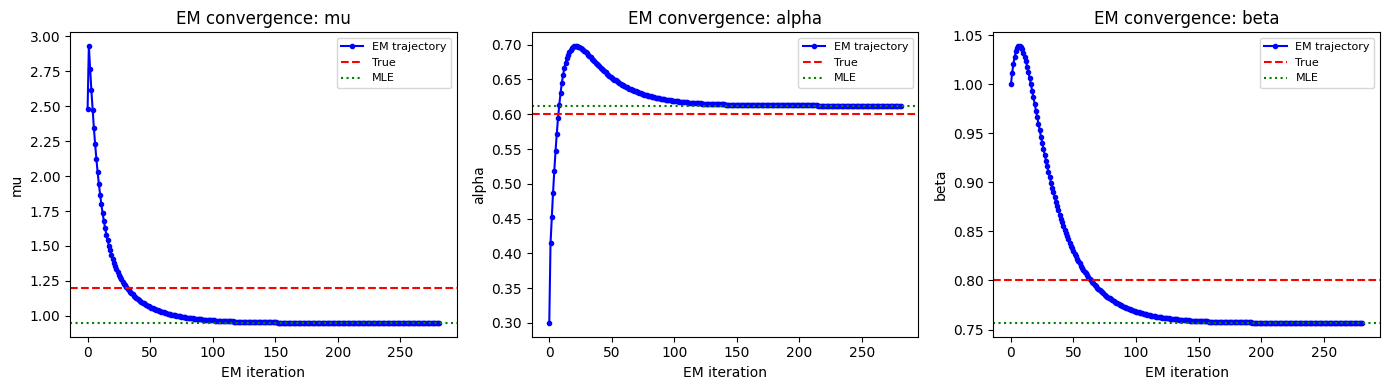

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, name, true_v, col in zip(
    axes, param_names, true_arr, range(3)
):
    ax.plot(em_hist[:, col], 'b.-', label='EM trajectory')
    ax.axhline(true_v, color='r', ls='--', label='True')
    ax.axhline(
        mle_est[col], color='g', ls=':', label='MLE'
    )
    ax.set_xlabel('EM iteration')
    ax.set_ylabel(name)
    ax.set_title(f'EM convergence: {name}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

EM and MLE converge to the same point (likelihood maximum), not necessarily the true parameters this is normal single-sample variability  both are consistent estimators asymptotically.

### Systematic comparison

We run both estimators on many independent samples and compare bias,
variance, and computation time.

In [20]:
mle_ests = np.zeros((N_COMP, 3))
em_ests = np.zeros((N_COMP, 3))
mle_ts = np.zeros(N_COMP)
em_ts = np.zeros(N_COMP)

for i in range(N_COMP):
    ev = simulate_hawkes_thinning(
        mu_true, alpha_true, beta_true, T_COMP
    )
    if len(ev) < 10:
        mle_ests[i] = np.nan
        em_ests[i] = np.nan
        continue
    t0 = time.perf_counter()
    mle_ests[i] = fit_hawkes_mle(ev, T_COMP)
    mle_ts[i] = time.perf_counter() - t0
    t0 = time.perf_counter()
    em_ests[i], _ = fit_hawkes_em(ev, T_COMP)
    em_ts[i] = time.perf_counter() - t0

mask = ~np.isnan(mle_ests[:, 0])
mle_ests = mle_ests[mask]
em_ests = em_ests[mask]
mle_ts = mle_ts[mask]
em_ts = em_ts[mask]

In [21]:
header = (
    f'{"":<8s} {"MLE mean":>10s} {"MLE std":>10s} '
    f'{"EM mean":>10s} {"EM std":>10s} {"True":>8s}'
)
print(header)
print('-' * len(header))
for col, name in enumerate(param_names):
    print(
        f'{name:<8s} '
        f'{mle_ests[:, col].mean():10.4f} '
        f'{mle_ests[:, col].std():10.4f} '
        f'{em_ests[:, col].mean():10.4f} '
        f'{em_ests[:, col].std():10.4f} '
        f'{true_arr[col]:8.4f}'
    )
print()
print(
    f'Average time: MLE={mle_ts.mean():.4f}s, '
    f'EM={em_ts.mean():.4f}s'
)

           MLE mean    MLE std    EM mean     EM std     True
-------------------------------------------------------------
mu           1.2950     0.2031     1.2952     0.2032   1.2000
alpha        0.5800     0.0605     0.5801     0.0604   0.6000
beta         0.7979     0.0945     0.7980     0.0944   0.8000

Average time: MLE=0.6044s, EM=13.3895s


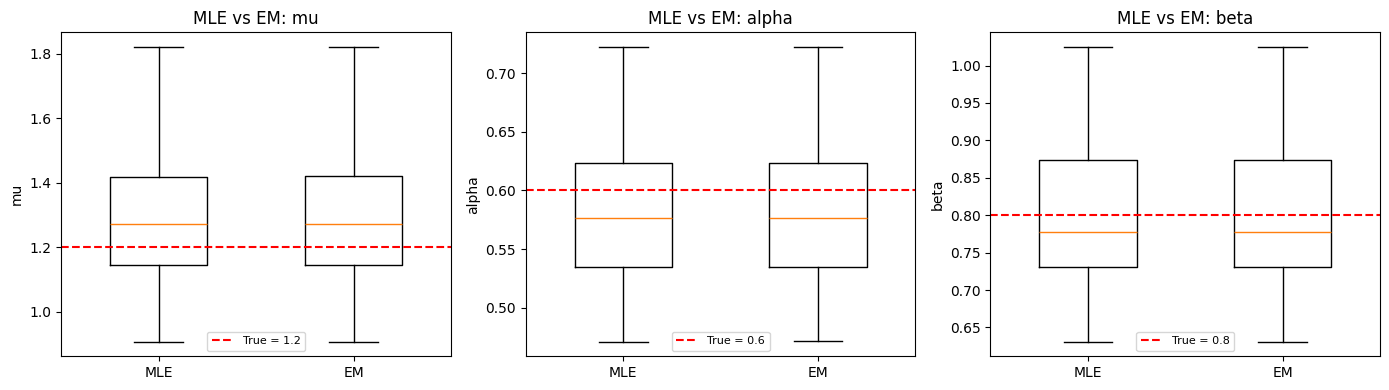

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, name, true_v, col in zip(
    axes, param_names, true_arr, range(3)
):
    ax.boxplot(
        [mle_ests[:, col], em_ests[:, col]],
        labels=['MLE', 'EM'], widths=0.5
    )
    ax.axhline(
        true_v, color='r', ls='--',
        label=f'True = {true_v}'
    )
    ax.set_ylabel(name)
    ax.set_title(f'MLE vs EM: {name}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

MLE and EM yield virtually identical distributions across all parameters, confirming both optimize the same likelihood.Medians are close to the true values (red), with symmetric spread, consistent with asymptotic unbiasedness.

### MSE as a function of the horizon T

In [ ]:
mse_mle = {T: [] for T in T_MSE}
mse_em = {T: [] for T in T_MSE}

for T in T_MSE:
    for _ in range(N_MSE):
        ev = simulate_hawkes_thinning(
            mu_true, alpha_true, beta_true, T
        )
        if len(ev) < 10:
            continue
        m = fit_hawkes_mle(ev, T)
        e, _ = fit_hawkes_em(ev, T)
        mse_mle[T].append(
            np.sum((m - true_arr) ** 2)
        )
        mse_em[T].append(
            np.sum((e - true_arr) ** 2)
        )

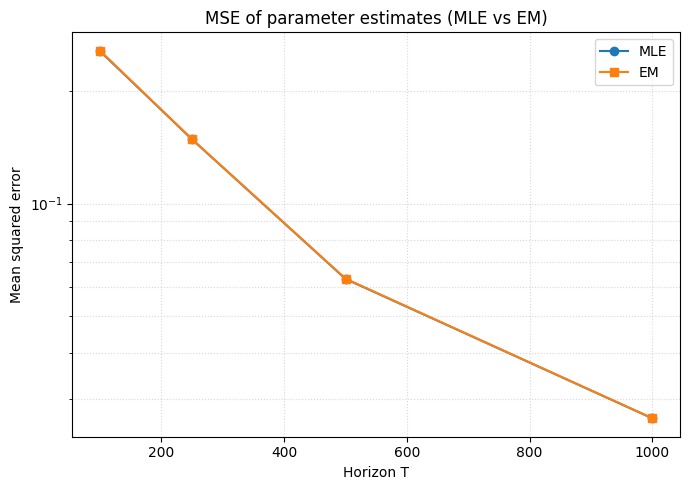

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    T_MSE,
    [np.mean(mse_mle[T]) for T in T_MSE],
    'o-', label='MLE'
)
ax.plot(
    T_MSE,
    [np.mean(mse_em[T]) for T in T_MSE],
    's-', label='EM'
)
ax.set_xlabel('Horizon T')
ax.set_ylabel('Mean squared error')
ax.set_title('MSE of parameter estimates (MLE vs EM)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout()
plt.show()

Both methods align and show consisent results, the MSE decreases with the horizon. 